# Zillow City Time-Series: Fast Time-Aware Training (XGBoost)

Goal: Prepare data from `Dataset/City_time_series.csv`, build a time-aware split, train fast models to predict next-month values for:
- `ZHVI_AllHomes`
- `ZHVIPerSqft_AllHomes`

Constraints:
- No leakage: only use information available at or before time t to predict t+1.
- Split train/test by time (not randomly).
- Normalize features using train-only statistics.
- Favor fast training (dataset is large) — use XGBoost with `tree_method='hist'` and early stopping.

Deliverables written to `models/` and `artifacts/`:
- Trained model files (per target), scaler, feature list, configs, and predictions.

Assumptions (auto-detected in code):
- Date column named `Date` (case-insensitive fallback supported).
- City/entity columns may include `RegionName`, `City`, `Metro`, `CountyName`, `StateName`, `RegionID` (the code picks what exists).
- Targets present among the columns; if a target is missing, its training is skipped gracefully.

In [30]:
# Imports and lightweight setup
import sys, json, math, os, gc, time, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

try:
    import xgboost as xgb
except ImportError:
    # Auto-install xgboost if missing (fast, CPU-only)
    import subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'xgboost>=2.0.0'])
    import xgboost as xgb

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

BASE_DIR = Path.cwd()
DATA_PATH = BASE_DIR / 'Dataset' / 'City_time_series.csv'
MODELS_DIR = BASE_DIR / 'models'
ARTIFACTS_DIR = BASE_DIR / 'artifacts'
MODELS_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

TIMESTAMP = time.strftime('%Y%m%d_%H%M%S')
TARGETS = ['ZHVI_AllHomes', 'ZHVIPerSqft_AllHomes']
ID_LIKE = {'RegionID','RegionName','City','Metro','CountyName','StateName','State','StateCodeFIPS','MunicipalCodeFIPS','SizeRank','CBSA','CSA','County','ZipCode'}

print('Using data at:', DATA_PATH)
print('Models ->', MODELS_DIR)
print('Artifacts ->', ARTIFACTS_DIR)

Using data at: c:\Users\USER\OneDrive\Desktop\realtyAI\Dataset\City_time_series.csv
Models -> c:\Users\USER\OneDrive\Desktop\realtyAI\models
Artifacts -> c:\Users\USER\OneDrive\Desktop\realtyAI\artifacts


In [31]:
# Load data with safe parsing and minimal memory overhead
def load_city_timeseries(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f'CSV not found: {path}')
    # parse dates for 'Date' (case-insensitive)
    # Use dtype inference; for big CSVs, specify low_memory=False
    df = pd.read_csv(path, low_memory=False)
    # Find date column
    date_col = None
    for c in df.columns:
        if c.lower() == 'date':
            date_col = c
            break
    if date_col is None:
        raise ValueError('No Date column found (case-insensitive match for "Date").')
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    # Drop rows with invalid dates
    df = df.dropna(subset=[date_col]).copy()
    return df, date_col

df_raw, DATE_COL = load_city_timeseries(DATA_PATH)
print('Loaded shape:', df_raw.shape)
print('Date column:', DATE_COL)
display(df_raw.head(3))

Loaded shape: (3762566, 81)
Date column: Date


,Date,RegionName,InventorySeasonallyAdjusted_AllHomes,InventoryRaw_AllHomes,MedianListingPricePerSqft_1Bedroom,MedianListingPricePerSqft_2Bedroom,MedianListingPricePerSqft_3Bedroom,MedianListingPricePerSqft_4Bedroom,MedianListingPricePerSqft_5BedroomOrMore,MedianListingPricePerSqft_AllHomes,...,ZHVI_BottomTier,ZHVI_CondoCoop,ZHVI_MiddleTier,ZHVI_SingleFamilyResidence,ZHVI_TopTier,ZRI_AllHomes,ZRI_AllHomesPlusMultifamily,ZriPerSqft_AllHomes,Zri_MultiFamilyResidenceRental,Zri_SingleFamilyResidenceRental
0,1996-04-30,abbottstownadamspa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,108700.0,NaN,NaN,NaN,NaN,NaN
1,1996-04-30,aberdeenbinghamid,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,168400.0,NaN,NaN,NaN,NaN,NaN
2,1996-04-30,aberdeenharfordmd,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,81300.0,137900.0,109600.0,108600.0,147900.0,NaN,NaN,NaN,NaN,NaN


In [32]:
# Identify entity (city) columns present and targets available
def detect_entity_columns(df: pd.DataFrame):
    candidates = [c for c in df.columns if c in ID_LIKE]
    # Prefer RegionName + StateName if present, else fallback to any available
    ordered_prefs = [
        ['RegionName','StateName'],
        ['RegionName'],
        ['City','StateName'],
        ['City'],
        ['Metro','StateName'],
        ['Metro'],
        ['CountyName','StateName'],
        ['CountyName'],
        ['RegionID']
    ]
    for grp in ordered_prefs:
        if all(g in df.columns for g in grp):
            return grp
    # Fallback to any id-like present
    if candidates:
        return candidates
    return []

entity_cols = detect_entity_columns(df_raw)
present_targets = [t for t in TARGETS if t in df_raw.columns]
print('Entity columns:', entity_cols)
print('Targets available:', present_targets)
if not present_targets:
    raise ValueError('None of the requested targets are present in the dataset.')

Entity columns: ['RegionName']
Targets available: ['ZHVI_AllHomes', 'ZHVIPerSqft_AllHomes']


In [34]:
# Preprocess: sort, feature selection (numeric only, exclude targets & IDs), imputation
def preprocess_features(df: pd.DataFrame, date_col: str, entity_cols: list, target_cols: list,
                        max_missing_frac: float = 0.4) -> pd.DataFrame:
    df = df.sort_values(by=entity_cols + [date_col]).reset_index(drop=True)
    # Identify numeric features
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    # Exclude targets & id-like columns from features
    drop_from_features = set(target_cols) | (set(entity_cols) & set(numeric_cols)) | (ID_LIKE & set(numeric_cols))
    feat_candidates = [c for c in numeric_cols if c not in drop_from_features]
    # Drop columns with too many missing
    valid_feats = []
    for c in feat_candidates:
        frac_missing = df[c].isna().mean()
        if frac_missing <= max_missing_frac:
            valid_feats.append(c)
    # Groupwise forward-fill then global median fill to avoid leakage across time within a city
    if entity_cols and len(valid_feats) > 0:
        df[valid_feats] = df.groupby(entity_cols, observed=True)[valid_feats].ffill()
    elif len(valid_feats) > 0:
        df[valid_feats] = df[valid_feats].ffill()
    if len(valid_feats) > 0:
        df[valid_feats] = df[valid_feats].fillna(df[valid_feats].median(numeric_only=True))
        # Ensure finiteness
        df[valid_feats] = df[valid_feats].replace([np.inf, -np.inf], np.nan)
        df[valid_feats] = df[valid_feats].fillna(df[valid_feats].median(numeric_only=True))
    return df, valid_feats

df_proc, feature_cols = preprocess_features(df_raw.copy(), DATE_COL, entity_cols, present_targets)
print('Feature count:', len(feature_cols))
print('Sample features:', feature_cols[:15])

Feature count: 7
Sample features: ['PctOfHomesDecreasingInValues_AllHomes', 'PctOfHomesIncreasingInValues_AllHomes', 'ZHVI_3bedroom', 'ZHVI_BottomTier', 'ZHVI_MiddleTier', 'ZHVI_SingleFamilyResidence', 'ZHVI_TopTier']


In [35]:
# Build supervised frames per target: X at time t, y = target at time t+1 (no leakage)
def build_supervised(df: pd.DataFrame, date_col: str, entity_cols: list, feature_cols: list,
                     target: str):
    df = df.copy()
    # y_date is the timestamp of the next month we predict
    if entity_cols:
        df['y'] = df.groupby(entity_cols, observed=True)[target].shift(-1)
        df['y_date'] = df.groupby(entity_cols, observed=True)[date_col].shift(-1)
    else:
        df['y'] = df[target].shift(-1)
        df['y_date'] = df[date_col].shift(-1)
    # Drop rows where y is NaN (last row per entity)
    mask = df['y'].notna() & df['y_date'].notna()
    sup = df.loc[mask, entity_cols + [date_col, 'y_date'] + feature_cols + ['y']].reset_index(drop=True)
    # Use y_date for splitting by the target timestamp
    return sup, 'y', 'y_date'

supervised_frames = {}
for tgt in present_targets:
    sup_df, y_col, y_date_col = build_supervised(df_proc, DATE_COL, entity_cols, feature_cols, tgt)
    supervised_frames[tgt] = (sup_df, y_col, y_date_col)
    print(tgt, 'supervised shape:', sup_df.shape)
    display(sup_df[[*entity_cols, DATE_COL, y_date_col, y_col]].head(3))

ZHVI_AllHomes supervised shape: (3072789, 11)


,RegionName,Date,y_date,y
0,abbevillelafayettems,1998-07-31,1998-08-31,76700.0
1,abbevillelafayettems,1998-08-31,1998-09-30,78400.0
2,abbevillelafayettems,1998-09-30,1998-10-31,79100.0


ZHVIPerSqft_AllHomes supervised shape: (2943165, 11)


,RegionName,Date,y_date,y
0,abbevillelafayettems,1999-07-31,1999-08-31,61.0
1,abbevillelafayettems,1999-08-31,1999-09-30,60.0
2,abbevillelafayettems,1999-09-30,1999-10-31,60.0


In [46]:
# Time-based split and scaling utilities
def time_split(sup: pd.DataFrame, y_col: str, y_date_col: str, train_frac: float = 0.8, val_frac_within_train: float = 0.1):
    unique_dates = np.array(sorted(sup[y_date_col].dropna().unique()))
    if len(unique_dates) < 5:
        raise ValueError('Not enough unique y_date values for a time-based split.')
    cutoff_idx = int(math.floor(len(unique_dates) * train_frac))
    cutoff_date = unique_dates[cutoff_idx - 1]
    train_part = sup[sup[y_date_col] <= cutoff_date].copy()
    test_part = sup[sup[y_date_col] > cutoff_date].copy()
    # Validation inside train based on time
    unique_train_dates = np.array(sorted(train_part[y_date_col].dropna().unique()))
    val_cut = int(max(1, math.floor(len(unique_train_dates) * (1.0 - val_frac_within_train))))
    val_start_date = unique_train_dates[val_cut - 1]
    train_final = train_part[train_part[y_date_col] <= val_start_date].copy()
    valid_final = train_part[train_part[y_date_col] > val_start_date].copy()
    return train_final, valid_final, test_part, cutoff_date


def scale_features(train_df, valid_df, test_df, feature_cols):
    scaler = StandardScaler()
    X_train = scaler.fit_transform(train_df[feature_cols])
    X_valid = scaler.transform(valid_df[feature_cols])
    X_test  = scaler.transform(test_df[feature_cols])
    return scaler, X_train, X_valid, X_test


def metrics(y_true, y_pred):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    mse = np.mean((y_true - y_pred) ** 2)
    rmse = float(np.sqrt(mse))
    mae  = float(np.mean(np.abs(y_true - y_pred)))
    # r2
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = float(1.0 - ss_res / ss_tot) if ss_tot > 0 else float('nan')
    return {'rmse': rmse, 'mae': mae, 'r2': r2}

In [43]:
# Model training and evaluation helpers (using native xgboost Booster API for compatibility)

def train_xgb_regressor(X_train, y_train, X_valid, y_valid, random_state: int = 42):
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dvalid = xgb.DMatrix(X_valid, label=y_valid)
    params = {
        'objective': 'reg:squarederror',
        'eta': 0.05,
        'max_depth': 7,
        'subsample': 0.9,
        'colsample_bytree': 0.8,
        'reg_alpha': 0.0,
        'reg_lambda': 1.0,
        'tree_method': 'hist',
        'eval_metric': 'rmse',
        'seed': random_state,
        'nthread': os.cpu_count() or 4,
    }
    booster = xgb.train(
        params=params,
        dtrain=dtrain,
        num_boost_round=600,
        evals=[(dvalid, 'valid')],
        early_stopping_rounds=50,
        verbose_eval=False
    )
    return booster


def evaluate_and_predict(model, X_valid, y_valid, X_test, y_test):
    dvalid = xgb.DMatrix(X_valid)
    dtest  = xgb.DMatrix(X_test)
    yv = model.predict(dvalid)
    yt = model.predict(dtest)
    m_val = metrics(y_valid, yv)
    m_tst = metrics(y_test, yt)
    return m_val, m_tst, yt

In [47]:
# Orchestrate training for each target and persist artifacts
all_results = {}
feature_artifact_path = ARTIFACTS_DIR / f'feature_columns_{TIMESTAMP}.json'
config_artifact_path  = ARTIFACTS_DIR / f'training_config_{TIMESTAMP}.json'

with open(feature_artifact_path, 'w') as f:
    json.dump({'feature_columns': feature_cols}, f, indent=2)

for tgt in present_targets:
    sup_df, y_col, y_date_col = supervised_frames[tgt]
    train_df, valid_df, test_df, cutoff_date = time_split(sup_df, y_col, y_date_col)

    # Scale using train-only stats
    scaler, X_train, X_valid, X_test = scale_features(train_df, valid_df, test_df, feature_cols)

    # Train (returns Booster)
    model = train_xgb_regressor(X_train, train_df[y_col].values, X_valid, valid_df[y_col].values)

    # Evaluate and predict
    m_val, m_tst, y_pred_test = evaluate_and_predict(model, X_valid, valid_df[y_col].values, X_test, test_df[y_col].values)
    print(f'[{tgt}] VAL:', m_val)
    print(f'[{tgt}] TEST:', m_tst)

    # Save model + scaler
    model_path_json = MODELS_DIR / f'xgb_city_{tgt}_{TIMESTAMP}.json'
    scaler_path     = ARTIFACTS_DIR / f'scaler_{tgt}_{TIMESTAMP}.joblib'
    model.save_model(model_path_json)
    joblib.dump(scaler, scaler_path)

    # Save test predictions with entity + y_date
    pred_df = test_df[entity_cols + [y_date_col]].copy()
    pred_df.rename(columns={y_date_col: 'TargetDate'}, inplace=True)
    pred_df[f'y_true_{tgt}'] = test_df[y_col].values
    pred_df[f'y_pred_{tgt}'] = y_pred_test
    preds_path = MODELS_DIR / f'predictions_test_{tgt}_{TIMESTAMP}.csv'
    pred_df.to_csv(preds_path, index=False)

    all_results[tgt] = {
        'val': m_val,
        'test': m_tst,
        'cutoff_date': str(pd.to_datetime(cutoff_date).date()),
        'model_json': str(model_path_json),
        'scaler': str(scaler_path),
        'test_predictions_csv': str(preds_path)
    }

with open(config_artifact_path, 'w') as f:
    json.dump({
        'timestamp': TIMESTAMP,
        'targets': present_targets,
        'date_col': DATE_COL,
        'entity_cols': entity_cols,
        'feature_columns_artifact': str(feature_artifact_path),
        'results': all_results
    }, f, indent=2)

print('Saved feature list to:', feature_artifact_path)
print('Saved training config to:', config_artifact_path)
pd.DataFrame(all_results).T

[ZHVI_AllHomes] VAL: {'rmse': 37199.53808230148, 'mae': 3766.339678493685, 'r2': 0.9538839323555778}
[ZHVI_AllHomes] TEST: {'rmse': 51671.81070739943, 'mae': 5417.053585421728, 'r2': 0.9457616349642353}
[ZHVIPerSqft_AllHomes] VAL: {'rmse': 23.350043551636098, 'mae': 12.270181523170889, 'r2': 0.9091760796298747}
[ZHVIPerSqft_AllHomes] TEST: {'rmse': 32.423172984250186, 'mae': 15.239486107283357, 'r2': 0.8972727169892862}
Saved feature list to: c:\Users\USER\OneDrive\Desktop\realtyAI\artifacts\feature_columns_20251031_213633.json
Saved training config to: c:\Users\USER\OneDrive\Desktop\realtyAI\artifacts\training_config_20251031_213633.json


,val,test,cutoff_date,model_json,scaler,test_predictions_csv
ZHVI_AllHomes,"{'rmse': 37199.53808230148, 'mae': 3766.339678...","{'rmse': 51671.81070739943, 'mae': 5417.053585...",2013-08-31,c:\Users\USER\OneDrive\Desktop\realtyAI\models...,c:\Users\USER\OneDrive\Desktop\realtyAI\artifa...,c:\Users\USER\OneDrive\Desktop\realtyAI\models...
ZHVIPerSqft_AllHomes,"{'rmse': 23.350043551636098, 'mae': 12.2701815...","{'rmse': 32.423172984250186, 'mae': 15.2394861...",2013-08-31,c:\Users\USER\OneDrive\Desktop\realtyAI\models...,c:\Users\USER\OneDrive\Desktop\realtyAI\artifa...,c:\Users\USER\OneDrive\Desktop\realtyAI\models...


In [48]:
# One-step-ahead forecast for next month after the last available date per entity
def build_latest_inference_frame(df: pd.DataFrame, date_col: str, entity_cols: list, feature_cols: list):
    # Get the last row per entity by date
    if entity_cols:
        idx = df.groupby(entity_cols, observed=True)[date_col].idxmax()
        latest = df.loc[idx, entity_cols + [date_col] + feature_cols].copy().reset_index(drop=True)
    else:
        latest = df.sort_values(date_col).tail(1)[[date_col] + feature_cols].copy().reset_index(drop=True)
    return latest

latest_frame = build_latest_inference_frame(df_proc, DATE_COL, entity_cols, feature_cols)

forecast_paths = {}
for tgt in present_targets:
    # Load corresponding scaler and model (Booster JSON)
    model_path_json = max(MODELS_DIR.glob(f'xgb_city_{tgt}_*.json'), key=os.path.getmtime)
    scaler_path     = max(ARTIFACTS_DIR.glob(f'scaler_{tgt}_*.joblib'), key=os.path.getmtime)
    booster = xgb.Booster()
    booster.load_model(model_path_json)
    scaler = joblib.load(scaler_path)
    X_latest = scaler.transform(latest_frame[feature_cols])
    y_next = booster.predict(xgb.DMatrix(X_latest))

    out = latest_frame[entity_cols + [DATE_COL]].copy()
    out.rename(columns={DATE_COL: 'LastObservedDate'}, inplace=True)
    out[f'forecast_t_plus_1_{tgt}'] = y_next
    out_path = MODELS_DIR / f'forecast_next_{tgt}_{TIMESTAMP}.csv'
    out.to_csv(out_path, index=False)
    forecast_paths[tgt] = str(out_path)

print('Saved next-step forecasts:', forecast_paths)
pd.DataFrame({'target': list(forecast_paths.keys()), 'forecast_csv': list(forecast_paths.values())})

Saved next-step forecasts: {'ZHVI_AllHomes': 'c:\\Users\\USER\\OneDrive\\Desktop\\realtyAI\\models\\forecast_next_ZHVI_AllHomes_20251031_213633.csv', 'ZHVIPerSqft_AllHomes': 'c:\\Users\\USER\\OneDrive\\Desktop\\realtyAI\\models\\forecast_next_ZHVIPerSqft_AllHomes_20251031_213633.csv'}


,target,forecast_csv
0,ZHVI_AllHomes,c:\Users\USER\OneDrive\Desktop\realtyAI\models...
1,ZHVIPerSqft_AllHomes,c:\Users\USER\OneDrive\Desktop\realtyAI\models...


## How to run
1. Ensure `Dataset/City_time_series.csv` exists (large file is okay).
2. Run cells top-to-bottom. If `xgboost` is missing, the notebook will install it automatically.
3. Outputs:
   - Models in `models/`: `xgb_city_<TARGET>_<timestamp>.joblib/json`
   - Artifacts in `artifacts/`: scaler(s), `feature_columns_<timestamp>.json`, `training_config_<timestamp>.json`
   - Test predictions: `models/predictions_test_<TARGET>_<timestamp>.csv`
   - One-step forecasts: `models/forecast_next_<TARGET>_<timestamp>.csv`

Notes:
- The pipeline avoids leakage by predicting t+1 using features at t and splitting by target month.
- Only numeric non-target columns are used as features; ID-like columns are excluded.
- Scaling uses train-only fit; the same scaler is applied to validation/test and saved for inference.
- Training uses early stopping to keep runtime fast on large data.

In [49]:
# Optional: Save Booster models as .joblib for convenience and update config JSON
from pathlib import Path

joblib_paths = {}
for tgt in present_targets:
    info = all_results.get(tgt, {})
    model_json = info.get('model_json')
    if not model_json:
        # Fallback to latest matching JSON if not in all_results
        cand = list(MODELS_DIR.glob(f'xgb_city_{tgt}_*.json'))
        if not cand:
            print(f'No JSON model found for {tgt}; skipping joblib save.')
            continue
        model_json = str(max(cand, key=os.path.getmtime))
    booster = xgb.Booster()
    booster.load_model(model_json)
    jl_path = str(Path(model_json).with_suffix('.joblib'))
    joblib.dump(booster, jl_path)
    joblib_paths[tgt] = jl_path
    print(f'Saved joblib model for {tgt} -> {jl_path}')

# Update training_config JSON with joblib paths if available
try:
    with open(config_artifact_path, 'r') as f:
        cfg = json.load(f)
    for tgt, jl in joblib_paths.items():
        if 'results' in cfg and tgt in cfg['results']:
            cfg['results'][tgt]['model_joblib'] = jl
    with open(config_artifact_path, 'w') as f:
        json.dump(cfg, f, indent=2)
    print('Updated config with joblib paths ->', config_artifact_path)
except Exception as e:
    print('Could not update training config JSON:', e)

Saved joblib model for ZHVI_AllHomes -> c:\Users\USER\OneDrive\Desktop\realtyAI\models\xgb_city_ZHVI_AllHomes_20251031_213633.joblib
Saved joblib model for ZHVIPerSqft_AllHomes -> c:\Users\USER\OneDrive\Desktop\realtyAI\models\xgb_city_ZHVIPerSqft_AllHomes_20251031_213633.joblib
Updated config with joblib paths -> c:\Users\USER\OneDrive\Desktop\realtyAI\artifacts\training_config_20251031_213633.json


In [50]:
# Compare actual vs predicted in column format and save a combined CSV
from pathlib import Path
import pandas as pd
import os, time

# Gather prediction CSVs per target (prefer paths from all_results)
pred_paths = {}
for tgt in present_targets:
    path = None
    if isinstance(all_results, dict) and tgt in all_results and 'test_predictions_csv' in all_results[tgt]:
        path = all_results[tgt]['test_predictions_csv']
    if not path:
        # Fallback to latest matching file
        cand = list(MODELS_DIR.glob(f'predictions_test_{tgt}_*.csv'))
        if cand:
            path = str(max(cand, key=os.path.getmtime))
    if path and os.path.exists(path):
        pred_paths[tgt] = path
    else:
        print(f'No predictions CSV found for {tgt}')

# Load and merge on entity columns + TargetDate
merged = None
frames = {}
for tgt, p in pred_paths.items():
    df = pd.read_csv(p)
    # Ensure required columns exist
    true_col = f'y_true_{tgt}'
    pred_col = f'y_pred_{tgt}'
    required = set(entity_cols + ['TargetDate', true_col, pred_col])
    missing = [c for c in required if c not in df.columns]
    if missing:
        print(f'{tgt}: missing columns in {p}:', missing)
        continue
    frames[tgt] = df[entity_cols + ['TargetDate', true_col, pred_col]].copy()
    merged = frames[tgt] if merged is None else pd.merge(
        merged, frames[tgt], on=entity_cols + ['TargetDate'], how='outer'
    )

if merged is None:
    print('No prediction frames to merge/display.')
else:
    # Sort for readability
    merged = merged.sort_values(entity_cols + ['TargetDate']).reset_index(drop=True)
    display(merged.head(20))
    # Save combined comparison
    ts = time.strftime('%Y%m%d_%H%M%S')
    combined_path = MODELS_DIR / f'predictions_test_COMBINED_{ts}.csv'
    merged.to_csv(combined_path, index=False)
    print('Saved combined comparison to:', combined_path)

,RegionName,TargetDate,y_true_ZHVI_AllHomes,y_pred_ZHVI_AllHomes,y_true_ZHVIPerSqft_AllHomes,y_pred_ZHVIPerSqft_AllHomes
0,abbevillelafayettems,2013-09-30,124800.0,126176.150,91.0,89.855170
1,abbevillelafayettems,2013-10-31,122300.0,125553.336,89.0,89.019250
2,abbevillelafayettems,2013-11-30,120200.0,123015.680,89.0,87.779594
3,abbevillelafayettems,2013-12-31,121300.0,121212.610,90.0,87.621460
4,abbevillelafayettems,2014-01-31,124800.0,121892.720,91.0,88.964165
5,abbevillelafayettems,2014-02-28,126600.0,125553.336,92.0,91.444470
6,abbevillelafayettems,2014-03-31,127500.0,127517.586,93.0,91.999596
7,abbevillelafayettems,2014-04-30,128600.0,128192.300,93.0,92.483560
8,abbevillelafayettems,2014-05-31,129900.0,128807.520,93.0,92.888230
9,abbevillelafayettems,2014-06-30,131000.0,130493.510,92.0,92.567090


Saved combined comparison to: c:\Users\USER\OneDrive\Desktop\realtyAI\models\predictions_test_COMBINED_20251031_220925.csv


In [53]:
# Create a 10-row sample input CSV for Streamlit (features only) from ZHVI_AllHomes test split
import time

TARGET_FOR_SAMPLE = 'ZHVI_AllHomes'
if TARGET_FOR_SAMPLE not in supervised_frames:
    raise ValueError(f'Target {TARGET_FOR_SAMPLE} not available in supervised_frames.')

sup_df, y_col, y_date_col = supervised_frames[TARGET_FOR_SAMPLE]
train_df, valid_df, test_df, cutoff_date = time_split(sup_df, y_col, y_date_col)

# Take first 10 rows of the test split FEATURES ONLY (align with feature_cols)
sample_features = test_df[feature_cols].head(10).copy()

# Write to project root as testzillow.csv
sample_path = BASE_DIR / 'testzillow.csv'
sample_features.to_csv(sample_path, index=False)
print('Saved 10-row sample features to:', sample_path)

Saved 10-row sample features to: c:\Users\USER\OneDrive\Desktop\realtyAI\testzillow.csv


## Forecast next 3 years of price (36 months)

This section adds a utility to forecast 36 months ahead from any monthly price time series (e.g., ZHVI or median sale price).

In [2]:
from __future__ import annotations
import warnings
from dataclasses import dataclass
from typing import Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings('ignore')

@dataclass
class ForecastResult:
    history: pd.Series
    forecast: pd.Series
    conf_int: pd.DataFrame  # columns: lower, upper


def _ensure_monthly_series(df_or_series: pd.DataFrame | pd.Series,
                           date_col: Optional[str] = None,
                           value_col: Optional[str] = None) -> pd.Series:
    """
    Coerce input into a monthly, datetime-indexed Series.
    Rules:
    - If a Series is passed with a DatetimeIndex, resample to monthly if needed.
    - If a DataFrame is passed, require date_col and value_col, then set index and resample monthly.
    - Aggregation: if multiple rows per month, take mean; if gaps, forward-fill when modeling.
    """
    if isinstance(df_or_series, pd.Series):
        s = df_or_series.copy()
        if not isinstance(s.index, pd.DatetimeIndex):
            raise ValueError("Series must have a DatetimeIndex. Pass a DataFrame with date_col and value_col instead.")
        s = s.sort_index()
    else:
        if not date_col or not value_col:
            raise ValueError("For a DataFrame input, provide both date_col and value_col.")
        df = df_or_series.copy()
        df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
        df = df.dropna(subset=[date_col])
        df = df.sort_values(date_col)
        s = df.set_index(date_col)[value_col].astype(float)
    # Resample to monthly frequency
    s_m = s.resample('MS').mean()  # month start
    # Minimal cleaning: fill isolated missing by interpolation, then backfill leading
    s_m = s_m.interpolate(limit_direction='both')
    return s_m


def _fit_sarimax_auto(y: pd.Series, seasonal_periods: int = 12) -> Tuple[Tuple[int,int,int], Tuple[int,int,int,int]]:
    """
    Tiny AIC-based grid search over a conservative set of SARIMAX orders
    to keep it robust and fast in notebooks.
    Returns ((p,d,q), (P,D,Q,s)).
    """
    # Ensure stationarity order guesses
    # We'll try d in {0,1} and seasonal D in {0,1}
    cand_p = [0, 1, 2]
    cand_d = [0, 1]
    cand_q = [0, 1, 2]

    cand_P = [0, 1]
    cand_D = [0, 1]
    cand_Q = [0, 1]

    best_aic = np.inf
    best_order = None
    best_seasonal = None

    for p in cand_p:
        for d in cand_d:
            for q in cand_q:
                for P in cand_P:
                    for D in cand_D:
                        for Q in cand_Q:
                            try:
                                model = SARIMAX(
                                    y,
                                    order=(p, d, q),
                                    seasonal_order=(P, D, Q, seasonal_periods),
                                    enforce_stationarity=False,
                                    enforce_invertibility=False,
                                )
                                res = model.fit(disp=False)
                                if res.aic < best_aic:
                                    best_aic = res.aic
                                    best_order = (p, d, q)
                                    best_seasonal = (P, D, Q, seasonal_periods)
                            except Exception:
                                continue
    # Fallback if everything failed (unlikely)
    if best_order is None:
        best_order = (1, 1, 1)
        best_seasonal = (1, 1, 1, seasonal_periods)
    return best_order, best_seasonal


def forecast_next_36_months(df_or_series: pd.DataFrame | pd.Series,
                            date_col: Optional[str] = None,
                            value_col: Optional[str] = None,
                            seasonal_periods: int = 12,
                            conf_alpha: float = 0.05) -> ForecastResult:
    """
    Build a 36-month ahead forecast with SARIMAX.

    Inputs
    - df_or_series: DataFrame with date/value columns, or a Series with a DatetimeIndex
    - date_col, value_col: required when passing a DataFrame
    - seasonal_periods: for monthly data use 12

    Outputs
    - ForecastResult with original history, point forecasts, and 95% conf intervals.
    """
    y = _ensure_monthly_series(df_or_series, date_col=date_col, value_col=value_col)
    # Fit simple auto SARIMAX
    order, seas = _fit_sarimax_auto(y, seasonal_periods)
    model = SARIMAX(y, order=order, seasonal_order=seas, enforce_stationarity=False, enforce_invertibility=False)
    res = model.fit(disp=False)

    horizon = 36
    fcast = res.get_forecast(steps=horizon)
    pred_mean = fcast.predicted_mean
    conf = fcast.conf_int(alpha=conf_alpha)
    conf.columns = ['lower', 'upper']

    return ForecastResult(history=y, forecast=pred_mean, conf_int=conf)


def plot_forecast(fr: ForecastResult, title: str = "36month price forecast"):
    plt.figure(figsize=(10, 4.5))
    fr.history.plot(label="history", color="#4f46e5")
    fr.forecast.plot(label="forecast", color="#10b981")
    plt.fill_between(fr.conf_int.index, fr.conf_int['lower'], fr.conf_int['upper'], color="#10b981", alpha=0.15, label="95% CI")
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend()
    plt.tight_layout()
    plt.show()

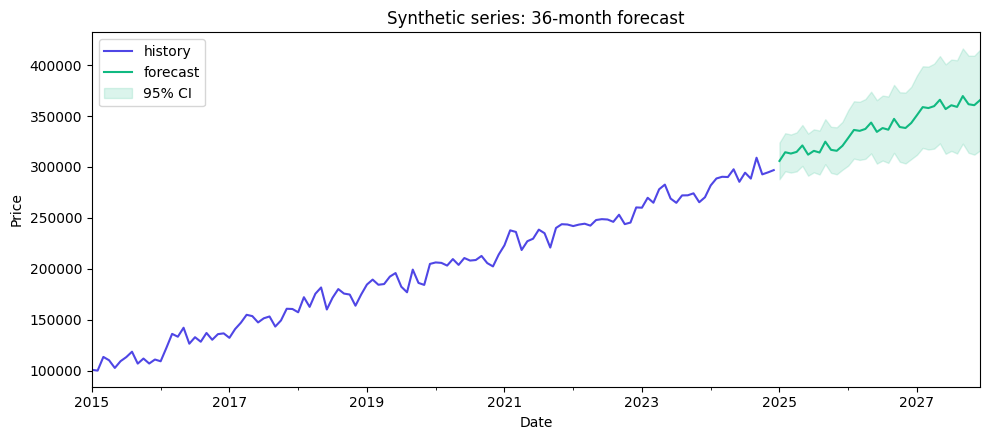

In [3]:
# Quick self-test on a synthetic monthly series so you can verify the function works
import numpy as np
import pandas as pd

rng = pd.date_range("2015-01-01", periods=120, freq="MS")
# Create a synthetic upward-trending, seasonal series
trend = np.linspace(100_000, 300_000, len(rng))
season = 5_000 * np.sin(2 * np.pi * np.arange(len(rng)) / 12)
noise = np.random.normal(0, 6_000, len(rng))
series = pd.Series(trend + season + noise, index=rng, name="price")

_fr = forecast_next_36_months(series)
plot_forecast(_fr, title="Synthetic series: 36-month forecast")

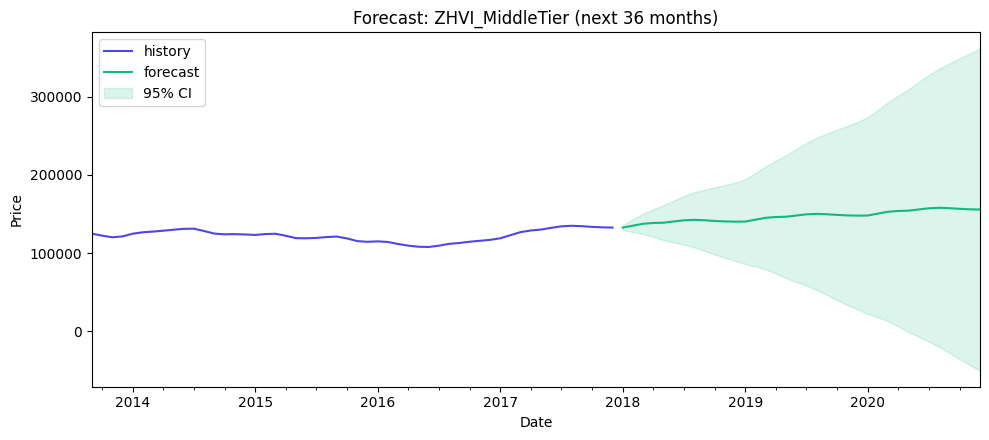

,date,forecast,lower_95,upper_95
0,2018-01-01,132629.554026,129533.779808,135725.328243
1,2018-02-01,135048.528722,126900.673976,143196.383467
2,2018-03-01,137483.444429,124502.838511,150464.050348
3,2018-04-01,138484.229581,120738.971208,156229.487954
4,2018-05-01,138872.992865,116485.869800,161260.115929
5,2018-06-01,140419.873931,113554.132891,167285.614972


In [7]:
# Example: Forecast next 36 months from your dataset
# Point this at a CSV with a monthly date column and a price-like column (e.g., ZHVI_AllHomes or Sale_Prices)
# If your file is large, consider filtering to one city/region first to keep it snappy.

import pandas as pd

# --- Configure these inputs for your file ---
CSV_PATH = r"testing/zillow1.csv"  # change if needed
DATE_COL = "Date"                               # e.g., 'Date' or 'date'
VALUE_COL = "ZHVI_MiddleTier"                     # e.g., 'ZHVI_AllHomes' or 'Sale_Prices'
# Optional: filter to a single city/region if your file is wide/long
ENTITY_COL = None                                # e.g., 'RegionName' or 'City'
ENTITY_VALUE = None                              # e.g., 'San Francisco'

try:
    usecols = None  # or [DATE_COL, VALUE_COL, ENTITY_COL] if you want faster reads
    df_big = pd.read_csv(CSV_PATH, usecols=usecols)
    if ENTITY_COL and ENTITY_VALUE and ENTITY_COL in df_big.columns:
        df_big = df_big[df_big[ENTITY_COL] == ENTITY_VALUE]
    fr = forecast_next_36_months(df_big, date_col=DATE_COL, value_col=VALUE_COL)
    plot_forecast(fr, title=f"Forecast: {VALUE_COL} (next 36 months)")

    # Show tabular output
    out = pd.DataFrame({
        'date': fr.forecast.index,
        'forecast': fr.forecast.values,
        'lower_95': fr.conf_int['lower'].values,
        'upper_95': fr.conf_int['upper'].values,
    })
    display(out.head(6))
except FileNotFoundError:
    print(f"File not found: {CSV_PATH}. Update CSV_PATH to your file.")
except Exception as e:
    print("Forecast failed:", e)